In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
import pandas as pd

df = pd.read_csv("../data/online_retail_clean.csv")

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Month', 'Sales'],
      dtype='object')

In [4]:
import datetime as dt

# Make sure InvoiceDate is datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Snapshot date (one day after the last purchase)
snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

# Create RFM table
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [10]:
rfm.describe()

,Recency,Frequency,Monetary,Cluster
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712,0.284091
std,96.860633,8.170213,8911.755977,0.532626
min,1.000000,1.000000,2.950000,0.000000
25%,18.000000,1.000000,307.187500,0.000000
50%,53.000000,2.000000,701.615000,0.000000
75%,136.000000,5.000000,1714.932500,1.000000
max,374.000000,205.000000,349164.350000,3.000000


In [21]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.03,4.46,1706.41
1,242.84,1.66,580.55
2,5.60,31.00,20004.39
3,14.91,29.02,17306.30


In [11]:
print("Number of customers:", rfm.shape[0])

Number of customers: 4312


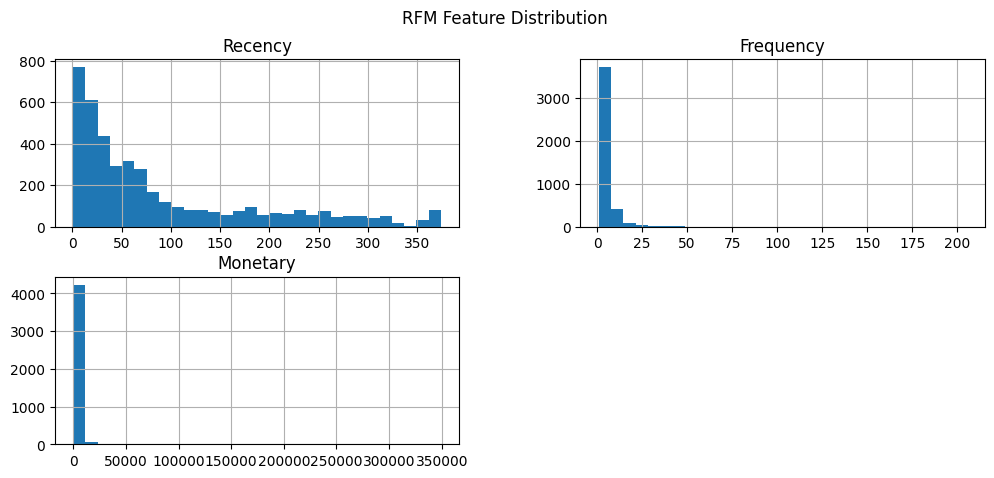

In [12]:
rfm[["Recency", "Frequency", "Monetary"]].hist(
    figsize=(12, 5),
    bins=30
)

plt.suptitle("RFM Feature Distribution")
plt.show()

In [13]:
for column in ["Recency", "Frequency", "Monetary"]:
    lower = rfm[column].quantile(0.01)
    upper = rfm[column].quantile(0.99)

    rfm[column] = rfm[column].clip(lower, upper)

In [14]:
rfm.describe()

,Recency,Frequency,Monetary,Cluster
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,91.137987,4.126160,1656.856389,0.284091
std,96.762984,4.909465,2894.379585,0.532626
min,1.000000,1.000000,40.586400,0.000000
25%,18.000000,1.000000,307.187500,0.000000
50%,53.000000,2.000000,701.615000,0.000000
75%,136.000000,5.000000,1714.932500,1.000000
max,368.000000,31.000000,20004.390600,3.000000


In [15]:
rfm_features = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]]

In [16]:
rfm_features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [18]:
rfm_scaled[:5]

array([[ 0.76341774,  1.40028246, -0.44366859,  1.34426856],
       [-0.91097034, -0.43312381, -0.11524925, -0.53343991],
       [-0.17713359, -0.63683561, -0.49574105, -0.53343991],
       [-0.49754118, -0.229412  ,  0.35047277, -0.53343991],
       [-0.82828451, -0.63683561, -0.46852308, -0.53343991]])

In [19]:
inertia = []
silhouette_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

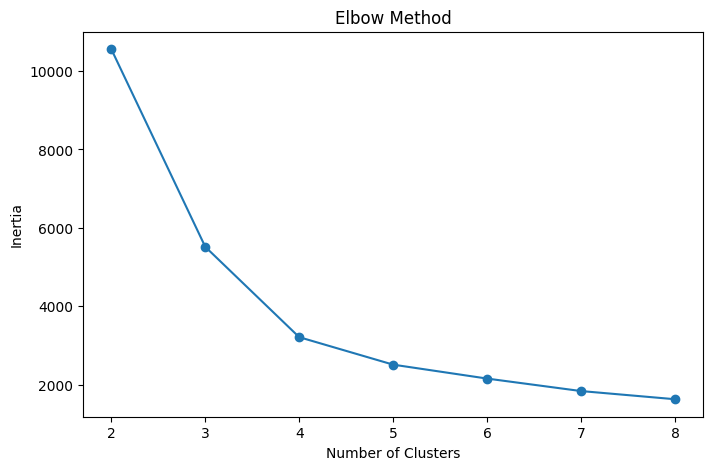

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

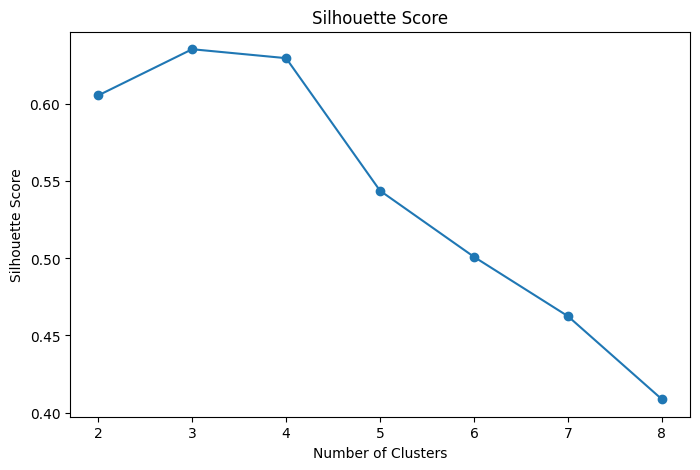

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

# Train Final K-Means Model

In [25]:
best_k=4
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [26]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,2
12347.0,3,2,1323.32,1
12348.0,74,1,222.16,1
12349.0,43,3,2671.14,1
12351.0,11,1,300.93,1


In [27]:
rfm["Cluster"].value_counts().sort_index()


Cluster
0     469
1    2736
2    1046
3      61
Name: count, dtype: int64

# Analyze the Clusters

In [28]:
cluster_summary = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,23.38,12.28,5762.83
1,46.48,3.11,1017.76
2,242.81,1.66,561.98
3,14.15,29.18,17527.45


In [29]:
cluster_names = {
    0: "Loyal High-Value Customers",
    1: "Regular Customers",
    2: "At-Risk Customers",
    3: "VIP Customers"
}

In [30]:
rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

In [31]:
rfm[["Recency", "Frequency", "Monetary", "Cluster", "Customer Segment"]].head(10)

,Recency,Frequency,Monetary,Cluster,Customer Segment
Customer ID,,,,,
12346.0,165,11,372.86,2,At-Risk Customers
12347.0,3,2,1323.32,1,Regular Customers
12348.0,74,1,222.16,1,Regular Customers
12349.0,43,3,2671.14,1,Regular Customers
12351.0,11,1,300.93,1,Regular Customers
12352.0,11,2,343.80,1,Regular Customers
12353.0,44,1,317.76,1,Regular Customers
12355.0,203,1,488.21,2,At-Risk Customers
12356.0,16,3,3560.30,1,Regular Customers


In [32]:
rfm["Customer Segment"].value_counts()

Customer Segment
Regular Customers             2736
At-Risk Customers             1046
Loyal High-Value Customers     469
VIP Customers                   61
Name: count, dtype: int64

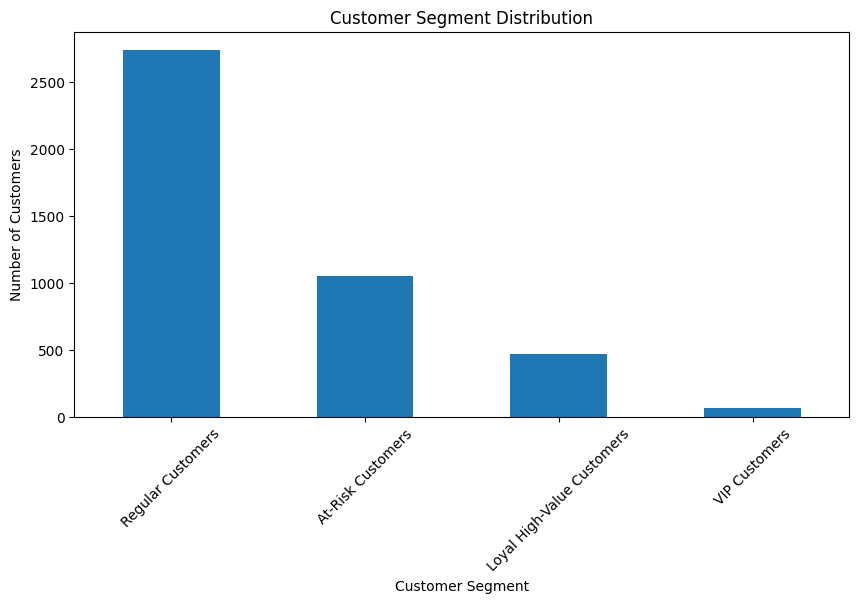

In [33]:
rfm["Customer Segment"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

# Customer Segmentation Visualization

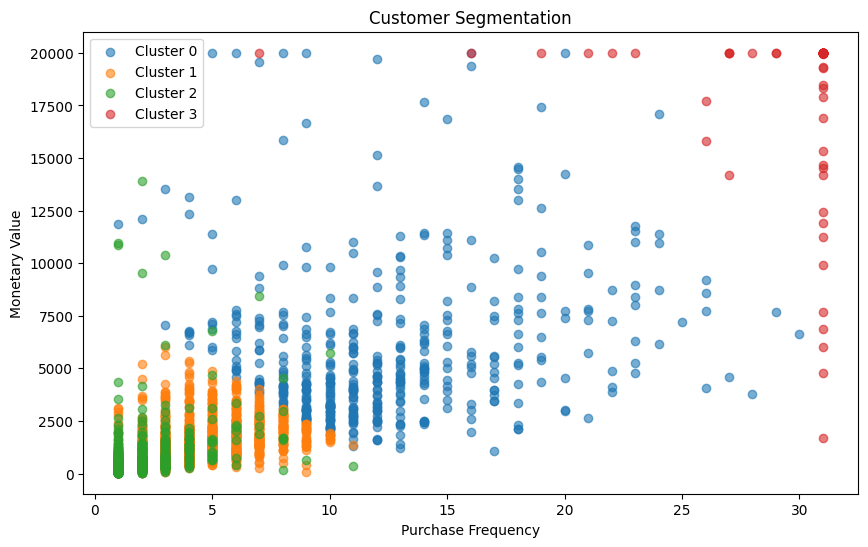

In [34]:
plt.figure(figsize=(10, 6))

for cluster in sorted(rfm["Cluster"].unique()):

    cluster_data = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation")
plt.legend()

plt.show()

In [35]:
# calculate final silhoutte score
final_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 3))

Final Silhouette Score: 0.63


In [36]:
rfm.to_csv(
    "../data/customer_segments.csv"
)

In [37]:
import joblib

joblib.dump(
    kmeans,
    "../models/customer_segmentation_kmeans.pkl"
)

['../models/customer_segmentation_kmeans.pkl']

In [38]:
joblib.dump(
    scaler,
    "../models/rfm_scaler.pkl"
)

['../models/rfm_scaler.pkl']

In [39]:
print("Customers:", len(rfm))
print("Clusters:", rfm["Cluster"].nunique())
print("Silhouette Score:", round(final_silhouette, 3))

Customers: 4312
Clusters: 4
Silhouette Score: 0.63


In [40]:
display(rfm.head(10))

,Recency,Frequency,Monetary,Cluster,Customer Segment
Customer ID,,,,,
12346.0,165,11,372.86,2,At-Risk Customers
12347.0,3,2,1323.32,1,Regular Customers
12348.0,74,1,222.16,1,Regular Customers
12349.0,43,3,2671.14,1,Regular Customers
12351.0,11,1,300.93,1,Regular Customers
12352.0,11,2,343.80,1,Regular Customers
12353.0,44,1,317.76,1,Regular Customers
12355.0,203,1,488.21,2,At-Risk Customers
12356.0,16,3,3560.30,1,Regular Customers


In [41]:
display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,23.38,12.28,5762.83
1,46.48,3.11,1017.76
2,242.81,1.66,561.98
3,14.15,29.18,17527.45
